# Feature-Based Object Representation Using DAISY Descriptors

In [3]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 58.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import cv2
import numpy as np
from skimage.feature import daisy
# Load the image in grayscale
image = cv2.imread('result_image.png',
    cv2.IMREAD_GRAYSCALE)
# Compute DAISY feature descriptors
descs, descs_img = daisy(image,
    step = 180,
    radius = 58,
    rings = 2,
    histograms = 6,
    orientations = 8,
    visualize=True)
# Convert the descriptors image from grayscale to RGB
descs_img = cv2.cvtColor(descs_img,
                         cv2.COLOR_GRAY2RGB)
# Show the image with DAISY descriptors
plt.imshow(descs_img)

error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::{anonymous}::CvtHelper<VScn, VDcn, VDepth, sizePolicy>::CvtHelper(cv::InputArray, cv::OutputArray, int) [with VScn = cv::impl::{anonymous}::Set<1>; VDcn = cv::impl::{anonymous}::Set<3, 4>; VDepth = cv::impl::{anonymous}::Set<0, 2, 5>; cv::impl::{anonymous}::SizePolicy sizePolicy = cv::impl::<unnamed>::NONE; cv::InputArray = const cv::_InputArray&; cv::OutputArray = const cv::_OutputArray&]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 3


# Template Matching Using OpenCV

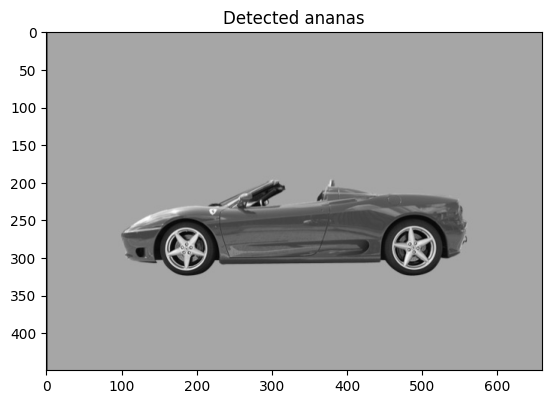

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load the image and the template
image = cv2.imread('car_green_screen.jpg',
    0)
template = cv2.imread('result_image.png',
    0)
w, h = template.shape[: : -1]
# Perform template matching
res = cv2.matchTemplate(image,
    template,
    cv2.TM_CCOEFF_NORMED)
# Set a threshold and find where
# the matching result exceeds it
threshold = 0.215
loc = np.where(res >= threshold)
# Create a copy of the original image
# in color to draw rectangles
color_image = cv2.cvtColor(image,
    cv2.COLOR_GRAY2BGR)
# Draw rectangles around the matched regions
for pt in zip(* loc[::-1]):
    cv2.rectangle(color_image,
        pt,
        (pt[0] + 2*w, pt[1] + 2*h),
        (25, 25, 25),
        2)
plt.imshow(color_image)
plt.title('Detected ananas')
plt.show()